<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica2Quest%C3%A3o7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando handel.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/handel.wav ...
Download concluido.

Sinal original: fs = 8192 Hz, N = 73113 amostras, duracao = 8.925 s

L = 2: fs_novo = 16384 Hz | N (manual) = 146226 | N (resample) = 146226
L = 4: fs_novo = 32768 Hz | N (manual) = 292452 | N (resample) = 292452
L = 8: fs_novo = 65536 Hz | N (manual) = 584904 | N (resample) = 584904


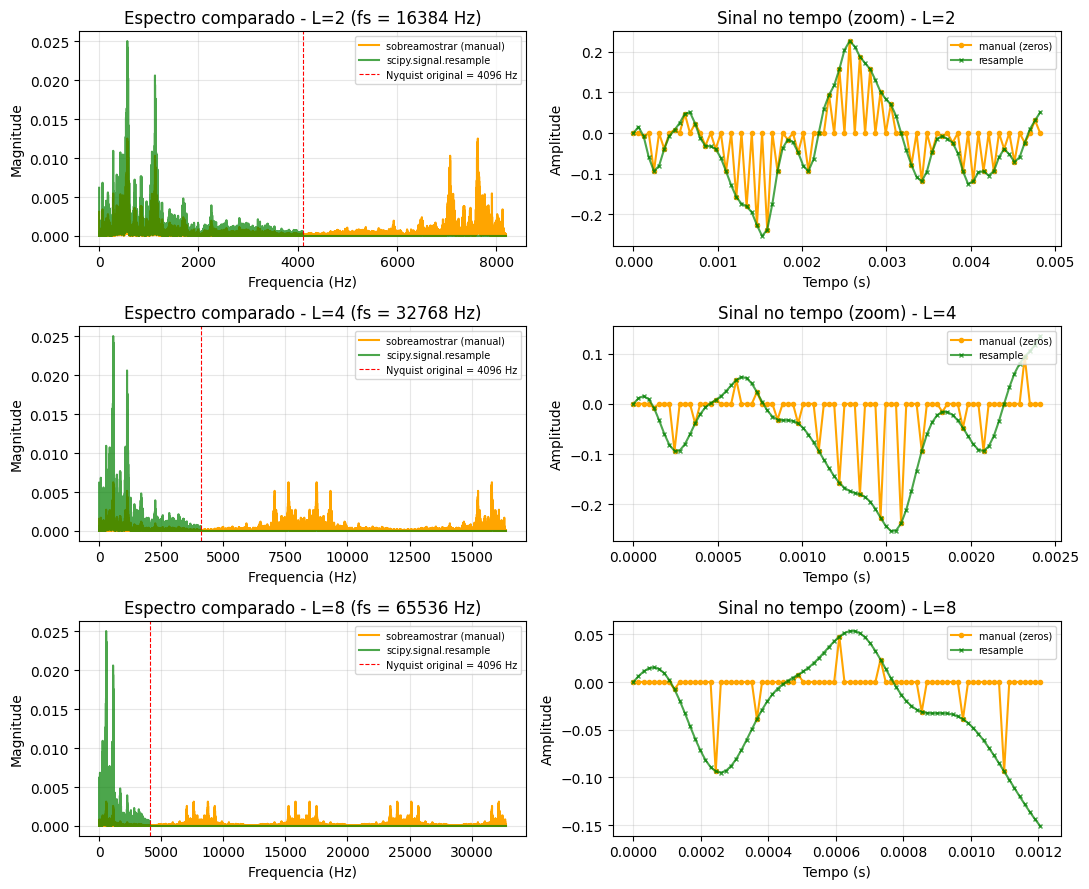


--- Audio original ---


--------------------------------------------------
Sobreamostrado L=2 (fs = 16384 Hz) - metodo MANUAL (zeros):


Sobreamostrado L=2 (fs = 16384 Hz) - metodo scipy.signal.resample:


--------------------------------------------------
Sobreamostrado L=4 (fs = 32768 Hz) - metodo MANUAL (zeros):


Sobreamostrado L=4 (fs = 32768 Hz) - metodo scipy.signal.resample:


--------------------------------------------------
Sobreamostrado L=8 (fs = 65536 Hz) - metodo MANUAL (zeros):


Sobreamostrado L=8 (fs = 65536 Hz) - metodo scipy.signal.resample:


--------------------------------------------------


In [ ]:
"""
Questao 7 - Repetir a sobreamostragem (Questao 6) utilizando scipy.signal.resample()
e comparar com os resultados obtidos pela funcao propria (sobreamostrar).

Diferenca conceitual importante:
    - sobreamostrar(x, L) -> insere L-1 zeros entre cada amostra original.
      Isso NAO adiciona informacao nova: no dominio da frequencia, gera
      L-1 replicas espectrais (imagens) do espectro original, espalhadas
      ao longo da nova banda [0, fs_novo/2]. Sem um filtro passa-baixas
      apos a insercao de zeros, essas replicas permanecem no sinal.

    - scipy.signal.resample(x, num) -> reamostragem via FFT: se 'num' for
      MAIOR que o numero de amostras original, o espectro e "preenchido
      com zeros" (zero-padding) no dominio da frequencia antes de voltar
      ao tempo via IFFT. Isso EQUIVALE a inserir zeros e ja filtrar
      (remover) as replicas espectrais automaticamente, entregando uma
      interpolacao suave do sinal, sem as imagens indesejadas.
"""

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import resample
import IPython.display as ipd


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.
    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# Funcao de sobreamostragem "manual" (mesma da Questao 6)
# ---------------------------------------------------------------------------
def sobreamostrar(x, L):
    """
    Sobreamostragem por insercao de zeros:
        y[n] = x[n/L],  se n = mL (m inteiro)
        y[n] = 0,       caso contrario
    """
    N = len(x)
    y = np.zeros(N * L)
    y[::L] = x
    return y


# ---------------------------------------------------------------------------
# Leitura do arquivo handel.wav (mesmo procedimento das questoes anteriores)
# ---------------------------------------------------------------------------
usar_colab = True

if usar_colab:
    url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
           "main/Aula_02/Sinais_Usados/handel.wav")
    caminho_arquivo = "handel.wav"
    if not os.path.exists(caminho_arquivo):
        print(f"Baixando {caminho_arquivo} de {url} ...")
        urllib.request.urlretrieve(url, caminho_arquivo)
        print("Download concluido.\n")
else:
    caminho_arquivo = "Aula_02/Sinais_Usados/handel.wav"

fs, x = wavfile.read(caminho_arquivo)

if x.ndim > 1:
    x = x[:, 0]

x = x.astype(np.float64)
x = x / np.max(np.abs(x))

N = len(x)
print(f"Sinal original: fs = {fs} Hz, N = {N} amostras, duracao = {N/fs:.3f} s\n")


# ---------------------------------------------------------------------------
# Sobreamostragem para L = 2, 4, 8, comparando as duas abordagens
# ---------------------------------------------------------------------------
fatores_L = [2, 4, 8]

sinais_manual = {}      # insercao de zeros, funcao propria (Questao 6)
sinais_resample = {}    # scipy.signal.resample

fig, eixos = plt.subplots(len(fatores_L), 2, figsize=(11, 9))

for i, L in enumerate(fatores_L):

    fs_novo = fs * L
    N_novo = N * L   # numero de amostras de saida (mesmo dos dois metodos)

    # --- Metodo 1: funcao propria (insercao de zeros) ---
    y_manual = sobreamostrar(x, L)
    sinais_manual[L] = (y_manual, fs_novo)
    freqs_manual, mag_manual = calculate_spectrum(y_manual, fs_novo)

    # --- Metodo 2: scipy.signal.resample (reamostragem via FFT) ---
    y_resample = resample(x, N_novo)
    sinais_resample[L] = (y_resample, fs_novo)
    freqs_resample, mag_resample = calculate_spectrum(y_resample, fs_novo)

    print(f"L = {L}: fs_novo = {fs_novo:.0f} Hz | "
          f"N (manual) = {len(y_manual)} | N (resample) = {len(y_resample)}")

    # --- Plot comparativo dos espectros ---
    eixos[i, 0].plot(freqs_manual, mag_manual, color='orange', label="sobreamostrar (manual)")
    eixos[i, 0].plot(freqs_resample, mag_resample, color='green', alpha=0.7,
                      label="scipy.signal.resample")
    eixos[i, 0].axvline(fs/2, color='red', linestyle='--', linewidth=0.8,
                         label=f"Nyquist original = {fs/2:.0f} Hz")
    eixos[i, 0].set_title(f"Espectro comparado - L={L} (fs = {fs_novo:.0f} Hz)")
    eixos[i, 0].set_xlabel("Frequencia (Hz)")
    eixos[i, 0].set_ylabel("Magnitude")
    eixos[i, 0].legend(loc="upper right", fontsize=7)
    eixos[i, 0].grid(True, alpha=0.3)

    # --- Plot comparativo dos sinais no tempo (zoom nas primeiras amostras) ---
    t_novo = np.arange(len(y_manual)) / fs_novo
    amostras_zoom = min(80, len(y_manual))
    eixos[i, 1].plot(t_novo[:amostras_zoom], y_manual[:amostras_zoom],
                      color='orange', marker='o', markersize=3, label="manual (zeros)")
    eixos[i, 1].plot(t_novo[:amostras_zoom], y_resample[:amostras_zoom],
                      color='green', marker='x', markersize=3, alpha=0.7, label="resample")
    eixos[i, 1].set_title(f"Sinal no tempo (zoom) - L={L}")
    eixos[i, 1].set_xlabel("Tempo (s)")
    eixos[i, 1].set_ylabel("Amplitude")
    eixos[i, 1].legend(loc="upper right", fontsize=7)
    eixos[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacao_resample_upsampling.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Ouvir os sinais gerados pelos dois metodos, para cada L
# ---------------------------------------------------------------------------
print("\n--- Audio original ---")
ipd.display(ipd.Audio(x, rate=fs, autoplay=False))
print('-' * 50)

for L in fatores_L:
    y_manual, fs_novo = sinais_manual[L]
    y_resample, _ = sinais_resample[L]

    print(f"Sobreamostrado L={L} (fs = {fs_novo:.0f} Hz) - metodo MANUAL (zeros):")
    ipd.display(ipd.Audio(y_manual, rate=fs_novo, autoplay=False))

    print(f"Sobreamostrado L={L} (fs = {fs_novo:.0f} Hz) - metodo scipy.signal.resample:")
    ipd.display(ipd.Audio(y_resample, rate=fs_novo, autoplay=False))
    print('-' * 50)

Comparação dos resultados obtidos com a função própria (sobreamostragem manual)

A função implementada no item (a), sobreamostrar(x, L), realiza a sobreamostragem exatamente como definida no enunciado: insere L−1 zeros entre cada duas amostras consecutivas do sinal original, sem aplicar nenhuma filtragem posterior. É por isso que, no gráfico do sinal no tempo (zoom), a curva laranja aparece com aquele padrão característico "em dente de serra" — picos abruptos seguidos por sequências de zeros — bem diferente da curva verde (resample), que é suave e contínua, acompanhando naturalmente a forma da onda original.

Essa diferença fica ainda mais evidente no domínio da frequência. O espectro obtido pela função manual apresenta, além da réplica original em banda base (0 a ~4096 Hz), réplicas espectrais adicionais espalhadas ao longo de toda a nova faixa de frequência — visíveis nos "blocos" de energia repetidos após a linha vermelha (Nyquist original), que aumentam em quantidade conforme L cresce (1 réplica extra para L=2, 3 para L=4, 7 para L=8). Já o espectro obtido por scipy.signal.resample() concentra toda a energia apenas na banda original (abaixo de 4096 Hz), sem nenhuma réplica visível nas frequências mais altas — confirmando que o resample() já filtra automaticamente essas imagens espectrais indesejadas.

Isso confirma que a função manual implementa corretamente a operação de sobreamostragem "pura" por inserção de zeros, tal como pedido no enunciado — mas evidencia, na prática, por que essa abordagem sozinha não é suficiente para uma interpolação de qualidade: sem um filtro passa-baixas após a inserção dos zeros, o sinal resultante carrega conteúdo espectral espúrio (as réplicas) que não existia no sinal original, e que se manifesta no tempo como aquelas transições abruptas entre amostra e zero, em vez de uma curva suave interpolada.

Sobre os áudios — apesar dessa diferença espectral, os players mostram a mesma duração (0:08) em todos os casos, e é esperado que os dois métodos soem parecidos ao ouvido humano nas frequências audíveis mais baixas — a diferença perceptual mais provável estaria em um leve chiado ou aspereza no áudio gerado pela função manual (decorrente das réplicas em alta frequência), enquanto a versão via resample() tende a soar mais "limpa", por já ter essas componentes filtradas.